# Lab 2: Predictive Analytics with Machine Learning

**Duration:** 2 weeks [18 Jun - 25 Jun, 2026]
**Due Date:** 25th June, 2026
**Format:** Jupyter Notebook / Google Colab
**Grading:** This is a graded lab.

**Student Name:** [Enter Name]
**Student ID:** [Enter ID]

---

### Objective

In this lab you will run a complete machine-learning workflow on **two real tabular datasets**,
covering both **supervised** and **unsupervised** learning:

| # | Task | Dataset | Type | Target |
|---|------|---------|------|--------|
| 1 | **Regression** | NYC Yellow Taxi trips | Supervised | `tip_amount` (continuous) |
| 2 | **Multi-class classification** | Obesity-level prediction | Supervised | `NObeyesdad` (7 classes) |
| 3 | **Clustering (K-Means)** | Obesity features (labels hidden) | Unsupervised | discover patient groups |

Along the way you will practise **NumPy, Pandas, and scikit-learn** to load and explore data,
clean and preprocess it, engineer features, split it into **train / validation / test** sets,
train models, **check for overfitting**, and discover hidden structure with clustering.

> **Note:** In this lab your *reasoning* is graded just as heavily as your *code*. Every section
> ends with a **Student Reasoning** box — fill it in with full sentences that justify your choices.

### Topics covered
Supervised learning (regression & classification), unsupervised learning (K-Means clustering),
feature engineering, train/validation/test splits, model evaluation, and overfitting.


---
### Part 0: Repository Setup *(done outside this notebook)*

1. Create a **public** repository named `lab-2-predictive-analytics` on GitHub/GitLab.
2. Clone it locally (or link it to Google Colab).
3. Save this notebook inside the repo as `lab_2_predictive_analytics.ipynb`.
4. Add a `requirements.txt` (provided with this lab) listing: `numpy pandas scikit-learn matplotlib seaborn`.
5. Commit and push your finished, fully-run notebook at the end.

**Local setup**
```bash
python -m venv .venv
source .venv/bin/activate        # Windows: .venv\Scripts\activate
pip install -r requirements.txt
jupyter lab
```

Open a new notebook, rename it, and run the cells below directly
(the datasets are loaded straight from their URLs, so no Drive mount is required).


In [ ]:
# Standard libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# You will import the specific scikit-learn modules you need inside each section.
# Example: from sklearn.model_selection import train_test_split

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", None)
RANDOM_STATE = 42   # use this everywhere so your results are reproducible

# Dataset URLs (already provided for you)
TAXI_URL    = "https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/pu9kbeSaAtRZ7RxdJKX9_A/yellow-tripdata.csv"
OBESITY_URL = "https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/GkDzb7bWrtvGXdPOfk6CIg/Obesity-level-prediction-dataset.csv"


---
# Section 1 — Supervised Learning: Regression
## Predicting taxi `tip_amount` (NYC Yellow Taxi)

Each row is a completed taxi trip. Your goal is to **predict the tip a passenger leaves**
(`tip_amount`, a continuous value) from the trip's characteristics. The available columns are:

`VendorID, passenger_count, trip_distance, RatecodeID, store_and_fwd_flag, PULocationID,
DOLocationID, payment_type, fare_amount, mta_tax, tolls_amount, improvement_surcharge, tip_amount`


### Part 1.1 — Load and explore the taxi data
Understand the shape, the data types, missing values, and the distribution of the target.

In [12]:
# TODO: Load the taxi dataset from TAXI_URL into a DataFrame called `taxi`
taxi = pd.read_csv(TAXI_URL)

# TODO: Inspect it
print(taxi.shape)
print(taxi.head())
taxi.info()
print(taxi.describe())
# - count missing values per column:
print(taxi.isna().sum())
# TODO: Visualise the distribution of the target `tip_amount`
#   (e.g. sns.histplot). Comment on its shape and any extreme values.


(41202, 13)
   VendorID  passenger_count  trip_distance  RatecodeID  store_and_fwd_flag  \
0         2                1          17.63           2                   1   
1         2                1          19.52           2                   1   
2         2                1          17.81           2                   1   
3         2                2          19.30           2                   1   
4         2                1          18.75           2                   1   

   PULocationID  DOLocationID  payment_type  fare_amount  mta_tax  \
0           132           164             1         70.0      0.5   
1           132           236             1         70.0      0.5   
2           132            48             1         70.0      0.5   
3           132           148             1         70.0      0.5   
4           132           234             1         70.0      0.5   

   tolls_amount  improvement_surcharge  tip_amount  
0          6.94                      1       

**Student Reasoning — Taxi data exploration**
*What is the shape of the data? Are there missing values or impossible values
(e.g. negative tips, zero-distance trips)? What does the `tip_amount` distribution look like
(skew, outliers, many zeros)? How will this influence your preprocessing?*

> **Answer:** [Double-click to edit]


### Part 1.2 — Preprocessing & feature engineering
Clean the data and create features that help predict the tip.

In [13]:
# TODO: Handle missing / invalid rows
#   e.g. drop or impute NaNs; remove rows where trip_distance <= 0 or fare_amount <= 0;
bola = pd.DataFrame(taxi)
bola = bola.dropna()
for i in bola.itertuples():
  if i.trip_distance<=0 or i.fare_amount<=0 or i.tip_amount<0:
    bola=bola.drop(i.Index)
#   decide how to treat negative tip_amount values.

# TODO: Feature engineering — create at least ONE new, justified feature, for example:
bola['total surcharges']= bola['mta_tax'] + bola['tolls_amount'] + bola['improvement_surcharge']
bola['fare-per-mile']= bola['fare_amount'] / bola['trip_distance']
#   - tip_rate proxy, fare-per-mile = fare_amount / trip_distance
#   - total surcharges = mta_tax + tolls_amount + improvement_surcharge
#   (Careful: do NOT leak the target. Do not build features directly from tip_amount.)

# TODO: Decide which columns are categorical (e.g. VendorID, RatecodeID, payment_type,
#   store_and_fwd_flag) vs numeric, and encode the categoricals (pd.get_dummies or OneHotEncoder).
for i in bola:
  if i == "VendorID" or i == "RatecodeID" or i == "store_and_fwd_flag" or i == "payment_type":
    bola=pd.get_dummies(bola, dtype=int)
  #else:
    #print()

# TODO: Scale the numeric features.
from sklearn.preprocessing import StandardScaler
 #(fit on TRAIN only — see Part 1.3)


In [ ]:
print(bola.dtypes)

VendorID                   int64
passenger_count            int64
trip_distance            float64
RatecodeID                 int64
store_and_fwd_flag         int64
PULocationID               int64
DOLocationID               int64
payment_type               int64
fare_amount              float64
mta_tax                  float64
tolls_amount             float64
improvement_surcharge      int64
tip_amount               float64
total surcharges         float64
fare-per-mile            float64
dtype: object


**Student Reasoning — Taxi preprocessing**
*1. How did you handle missing/invalid rows and why?*
*2. Which new feature(s) did you engineer and what is the intuition behind them?*
*3. Which scaling method did you choose and why is it appropriate here?*

> **Answer:** [Double-click to edit]


### Part 1.3 — Train / Validation / Test split
A three-way split lets you tune on validation data and keep the test set as a final, unbiased check.

In [ ]:
# TODO: Separate features (X) and target (y = tip_amount)

# TODO: Split into train / validation / test (a common choice is 60/20/20).
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
random_state=42
x=bola.drop('tip_amount',axis=1)
y=bola['tip_amount']
xtrain,xleft,ytrain,yleft=train_test_split(x,y,train_size=0.60,random_state=random_state)

valx1,valx2,valy1,valy2=train_test_split(xleft, yleft, test_size=0.50,random_state=random_state)
#   First split off the test set, then split the remainder into train + validation.
#   Use random_state=RANDOM_STATE.

# TODO: Fit your scaler on the TRAINING set only, then transform train, val, and test.
scaler=MinMaxScaler()
bingo=xtrain.select_dtypes(include=['int64','float64']).columns
scaledxtrain=xtrain.copy()
scaledval1=valx1.copy()
scaledval2=valx2.copy()

scaledxtrain[bingo]=scaler.fit_transform(xtrain[bingo])
scaledval1[bingo]=scaler.transform(valx1[bingo])
scaledval2[bingo]=scaler.transform(valx2[bingo])


#   (Explain in the reasoning box why scaling must be fit on train only.)


**Student Reasoning — Splitting**
*What ratio did you use? Why is a separate validation set useful in addition to a test set?
Why must the scaler (and any imputation statistics) be fit on the training data only?*

> **Answer:** [Double-click to edit]


### Part 1.4 — Train a regressor and check for overfitting
Train a model and evaluate it on **train, validation, and test** sets.

Linear Regression - Training
RSME: 4.817370072438601
 R2: 0.04876002484359454
Linear Regression - Validation
RSME: 4.7798759588696935
R2: 0.06874505470326964
Linear Regression - Test
 RMSE: 5.223940548022861
R2: 0.04008179273502288
RandomForestRegression - Training
RSME: 2.826176573313462
 R2: 0.6726075525177012
RandomForestRegression- Validation
RSME: 5.433984254780993
R2: -0.20357204064327195
RandomForestRegression- Test
 RMSE: 5.8185010495007745
R2: -0.19085809111543162


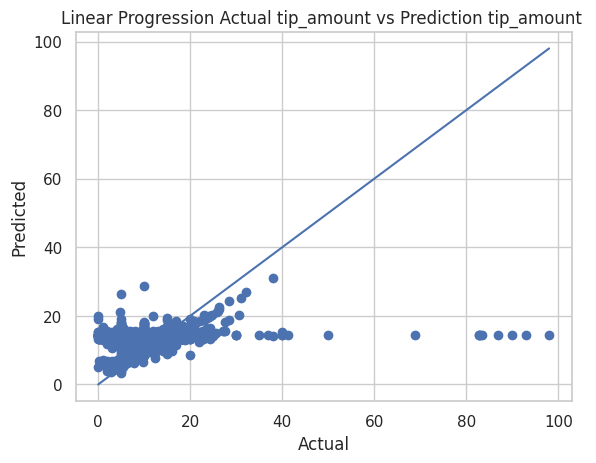

In [ ]:
# TODO: Import, initialise, and train a regression model.
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
model1 = LinearRegression()
model2=RandomForestRegressor(random_state=random_state)
model1.fit(scaledxtrain, ytrain)
model2.fit(scaledxtrain,ytrain)

prex1=model1.predict(scaledxtrain)
prex2=model1.predict(scaledval1)
prex3=model1.predict(scaledval2)

prey1=model2.predict(scaledxtrain)
prey2=model2.predict(scaledval1)
prey3=model2.predict(scaledval2)


#   Start simple (LinearRegression), then try a more flexible model
#   (e.g. RandomForestRegressor or DecisionTreeRegressor) and compare.

# TODO: Predict on train, validation, and test sets.

# TODO: Report RMSE and R^2 for ALL THREE sets.

from sklearn.metrics import mean_squared_error, r2_score
print('Linear Regression - Training')
RSMEtraining= mean_squared_error(ytrain, prex1) ** 0.5
print(f'RSME: {RSMEtraining}')
R2training=r2_score(ytrain, prex1)
print(f' R2: {R2training}')

print('Linear Regression - Validation')
RSMEval=mean_squared_error(valy1, prex2) ** 0.5
print(f'RSME: {RSMEval}')
R2val=r2_score(valy1, prex2)
print(f'R2: {R2val}')

print('Linear Regression - Test')
RSMEtest=mean_squared_error(valy2, prex3) ** 0.5
print(f' RMSE: {RSMEtest}')
R2test=r2_score(valy2, prex3)
print(f'R2: {R2test}')

print('RandomForestRegression - Training')
RSMEtraining2= mean_squared_error(ytrain, prey1) ** 0.5
print(f'RSME: {RSMEtraining2}')
R2training2=r2_score(ytrain, prey1)
print(f' R2: {R2training2}')

print('RandomForestRegression- Validation')
RSMEval2=mean_squared_error(valy1, prey2) ** 0.5
print(f'RSME: {RSMEval2}')
R2val2=r2_score(valy1, prey2)
print(f'R2: {R2val2}')

print('RandomForestRegression- Test')
RSMEtest2=mean_squared_error(valy2, prey3) ** 0.5
print(f' RMSE: {RSMEtest2}')
R2test2=r2_score(valy2, prey3)
print(f'R2: {R2test2}')









#   (RMSE = mean_squared_error(y_true, y_pred) ** 0.5)

# TODO: Plot predicted vs actual tip for the test set (a scatter with the y=x line).
import matplotlib.pyplot as plt
plt.scatter(valy2,prex3)
plt.title('Linear Progression Actual tip_amount vs Prediction tip_amount ')
plt.xlabel('Actual')
plt.ylabel('Predicted')
plt.plot([valy2.min(), valy2.max()],[valy2.min(), valy2.max()])
plt.show()

**Student Reasoning — Regression evaluation & overfitting**
*1. Which model performed best on the validation set, and which hyper-parameters did you try?*
*2. Compare TRAIN vs VALIDATION vs TEST metrics. Is the model overfitting, underfitting, or
well-fitted? Quote the specific numbers that back up your claim.*
*3. What would you change to reduce overfitting if you saw it?*

> **Answer:** [Double-click to edit]


---
# Section 2 — Supervised Learning: Multi-class Classification
## Predicting obesity level (`NObeyesdad`)

Each row describes a person's eating habits and physical condition. Predict their
**obesity category** `NObeyesdad`, which has **7 classes**: `Insufficient_Weight, Normal_Weight,
Overweight_Level_I, Overweight_Level_II, Obesity_Type_I, Obesity_Type_II, Obesity_Type_III`.

Feature columns: `Gender, Age, Height, Weight, family_history_with_overweight, FAVC, FCVC, NCP,
CAEC, SMOKE, CH2O, SCC, FAF, TUE, CALC, MTRANS`.


### Part 2.1 — Load and explore the obesity data
Look at the shape, dtypes, missing values, and especially the **class balance** of the target.

(2111, 17)
   Gender   Age  Height  Weight family_history_with_overweight FAVC  FCVC  \
0  Female  21.0    1.62    64.0                            yes   no   2.0   
1  Female  21.0    1.52    56.0                            yes   no   3.0   
2    Male  23.0    1.80    77.0                            yes   no   2.0   
3    Male  27.0    1.80    87.0                             no   no   3.0   
4    Male  22.0    1.78    89.8                             no   no   2.0   

   NCP       CAEC SMOKE  CH2O  SCC  FAF  TUE        CALC  \
0  3.0  Sometimes    no   2.0   no  0.0  1.0          no   
1  3.0  Sometimes   yes   3.0  yes  3.0  0.0   Sometimes   
2  3.0  Sometimes    no   2.0   no  2.0  1.0  Frequently   
3  3.0  Sometimes    no   2.0   no  2.0  0.0  Frequently   
4  1.0  Sometimes    no   2.0   no  0.0  0.0   Sometimes   

                  MTRANS           NObeyesdad  
0  Public_Transportation        Normal_Weight  
1  Public_Transportation        Normal_Weight  
2  Public_Transportat

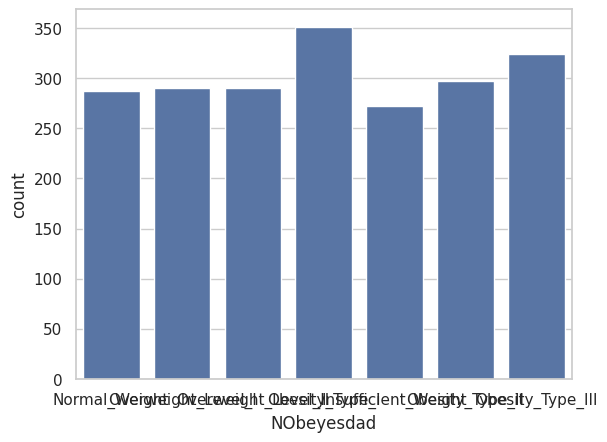

In [14]:
# TODO: Load the obesity dataset from OBESITY_URL into a DataFrame called `obesity`
obesity = pd.read_csv(OBESITY_URL)
# TODO: Inspect shape, head, info, describe, and missing values.
print(obesity.shape)
print(obesity.head())
obesity.info()
print(obesity.describe())
# - count missing values per column:
print(obesity.isna().sum())

# TODO: Show the class distribution of `NObeyesdad`
#   (value_counts and a sns.countplot). Is it balanced across the 7 classes?
import seaborn as sns
import matplotlib.pyplot as plt

# The standard syntax template
sns.countplot(data=obesity, x="NObeyesdad")
plt.show()

**Student Reasoning — Obesity data exploration**
*How many rows/features are there? Which columns are categorical vs numeric? Is the target
balanced across the 7 classes, and why does class (im)balance matter for classification?*

> **Answer:** [Double-click to edit]


### Part 2.2 — Preprocessing & feature engineering
Models need numeric input. Encode categoricals, scale numerics, and optionally add a feature.

In [15]:
# TODO: Encode categorical columns.
#   - Binary yes/no columns (family_history_with_overweight, FAVC, SMOKE, SCC) -> 0/1

obesity['family_history_with_overweight'] = obesity['family_history_with_overweight'].map({'yes': 1, 'no': 0})
obesity['FAVC'] = obesity['FAVC'].map({'yes': 1, 'no': 0})
obesity['SMOKE'] = obesity['SMOKE'].map({'yes': 1, 'no': 0})
obesity['SCC'] = obesity['SCC'].map({'yes': 1, 'no': 0})
#   - Ordinal-ish columns (CAEC, CALC) and nominal (Gender, MTRANS) -> choose an encoding
from sklearn.preprocessing import OrdinalEncoder
encoder = OrdinalEncoder()
obesity['CAEC'] = encoder.fit_transform(obesity[["CAEC"]])
obesity['CALC'] = encoder.fit_transform(obesity[["CALC"]])
obesity = pd.get_dummies(obesity, columns=['Gender'], dtype=int)
obesity = pd.get_dummies(obesity, columns=['MTRANS'], dtype=int)

#     and justify it (LabelEncoder / OrdinalEncoder / pd.get_dummies / OneHotEncoder).

# TODO (optional but encouraged): engineer a domain feature, e.g. BMI = Weight / Height**2.
#   Discuss whether including BMI makes the task "too easy" / leaks the target.

# TODO: Encode the target `NObeyesdad` into integer class labels
from sklearn.preprocessing import LabelEncoder
label_encoder = LabelEncoder()
obesity['NObeyesdad'] = label_encoder.fit_transform(obesity['NObeyesdad'])
# TODO: Scale the numeric features (fit on TRAIN only, in Part 2.3).


**Student Reasoning — Obesity preprocessing**
*1. How did you encode each type of categorical variable, and why?*

> Add blockquote

> Add blockquote

> Add blockquote






*2. Did you engineer any feature (e.g. BMI)? Argue whether it is fair to include given the
target is an obesity level.*
*3. Which scaler did you use and why?*

> **Answer:** [Double-click to edit]


### Part 2.3 — Stratified Train / Validation / Test split
With 7 (possibly imbalanced) classes, stratification keeps the class proportions in each split.

In [16]:
# TODO: Separate X (features) and y (encoded NObeyesdad).
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
random_state=42
x=obesity.drop('NObeyesdad',axis=1)
y=obesity['NObeyesdad']
xtrain,xleft,ytrain,yleft=train_test_split(x,y,train_size=0.60,random_state=random_state,stratify=y)

valx1,valx2,valy1,valy2=train_test_split(xleft, yleft, test_size=0.50,random_state=random_state, stratify=yleft)
# TODO: Split into train / validation / test using stratify=y so every split has all 7 classes.
#   Use random_state=RANDOM_STATE.
scaledxtrain = xtrain.copy()
scaledval1 = valx1.copy()
scaledval2 = valx2.copy()
scaler = MinMaxScaler()
bingo = xtrain.select_dtypes(include=['int64', 'float64']).columns

# TODO: Fit the scaler on the training set only, then transform train / val / test.
scaledxtrain[bingo]=scaler.fit_transform(xtrain[bingo])
scaledval1[bingo]=scaler.transform(valx1[bingo])
scaledval2[bingo]=scaler.transform(valx2[bingo])



**Student Reasoning — Splitting**
*What split ratio did you choose? Why is `stratify=y` important for this dataset?
i chose a 60:20:20 split which is for training, testing and validation respectively. stratify=y to ensure reliability in evaluation
What could go wrong if you split without stratifying?*
All of the obesity levels would not have been represented properly by the training,validation and testing
> **Answer:** [Double-click to edit]


### Part 2.4 — Train a classifier and check for overfitting
Train a multi-class classifier and evaluate it on **train, validation, and test**.

Testing
   Accuracy  Macro-F1
0  0.929078  0.928163
Validation
   Accuracy  Macro-F1
0   0.93128  0.930697
Training
   Accuracy  Macro-F1
0       1.0       1.0


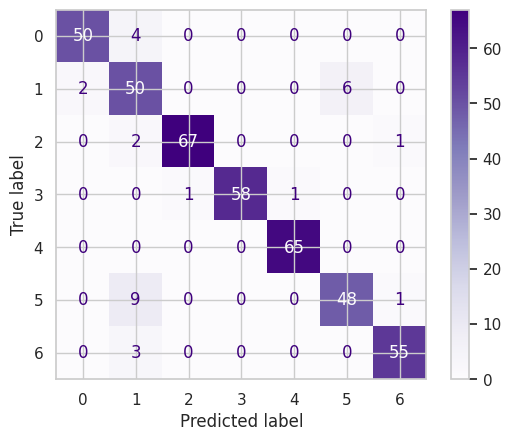

In [17]:
# TODO: Import, initialise, and train a classifier
from sklearn.ensemble import RandomForestClassifier
model1 = RandomForestClassifier(n_estimators=100, random_state=42)
model1.fit(scaledxtrain, ytrain)
prex1=model1.predict(scaledxtrain)
prex2=model1.predict(scaledval1)
prex3=model1.predict(scaledval2)

#   (e.g. LogisticRegression(max_iter=...), RandomForestClassifier, or KNeighborsClassifier).

# TODO: Predict on train, validation, and test.


# TODO: Report accuracy AND macro-F1 for ALL THREE sets
from sklearn.metrics import classification_report
report_dict1 = classification_report(valy2, prex3, output_dict=True)
report_dict2= classification_report(valy1, prex2, output_dict=True)
report_dict3 = classification_report(ytrain, prex1, output_dict=True)

metrics_df1 = pd.DataFrame([{
    'Accuracy': report_dict1['accuracy'],
    'Macro-F1': report_dict1['macro avg']['f1-score']
}])
print('Testing')
print(metrics_df1)

metrics_df2 = pd.DataFrame([{
    'Accuracy': report_dict2['accuracy'],
    'Macro-F1': report_dict2['macro avg']['f1-score']
}])
print('Validation')
print(metrics_df2)
metrics_df3 = pd.DataFrame([{
    'Accuracy': report_dict3['accuracy'],
    'Macro-F1': report_dict3['macro avg']['f1-score']
}])
print('Training')
print(metrics_df3)

# TODO: Show a confusion matrix for the test set
from sklearn.metrics import ConfusionMatrixDisplay

ConfusionMatrixDisplay.from_predictions(y_true=valy2,y_pred=prex3,cmap=plt.cm.Purples)
plt.show()
#   Which classes are most often confused?
# ANswer:class 5

**Student Reasoning — Classification evaluation & overfitting**
*1. Which classifier did you choose and why?*
Answer: I chose Random forest because it handles non linear patterns wellnon-linear patterns well
*2. Compare TRAIN vs VALIDATION vs TEST accuracy/F1. Is the model overfitting, underfitting,
or well-fitted? Cite the specific metrics.*

> Add blockquote
Overfitting. Training accuracy and F1 were 1.00, validation accuracy and test accuracy was about 0.93. The training score is okay but the validation and test score are different

*3. From the confusion matrix, which obesity levels are hardest to tell apart, and why might
that be?*
Class 1 and 5. This is because the obesity levels have similar body measurements or lifestyle features.
> **Answer:** [Double-click to edit]


---
# Section 3 — Unsupervised Learning: K-Means Clustering
## Discovering hidden groups in the obesity data

Now **pretend you never had the `NObeyesdad` labels.** Using only the *scaled feature matrix*
from Section 2, use **K-Means** to see whether people naturally fall into distinct profiles —
and then compare those clusters to the real obesity levels.


### Part 3.1 — Choose k, fit K-Means, and visualise


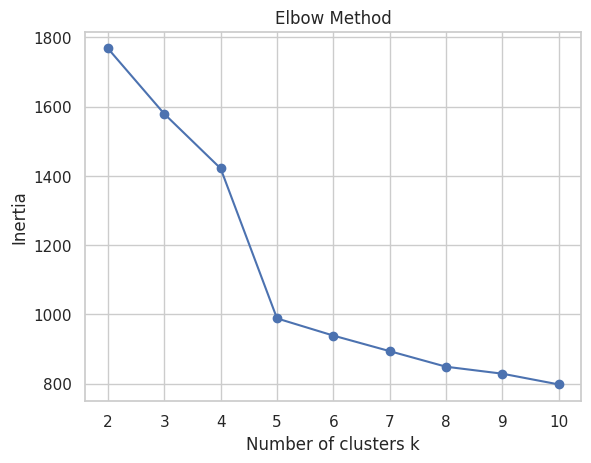

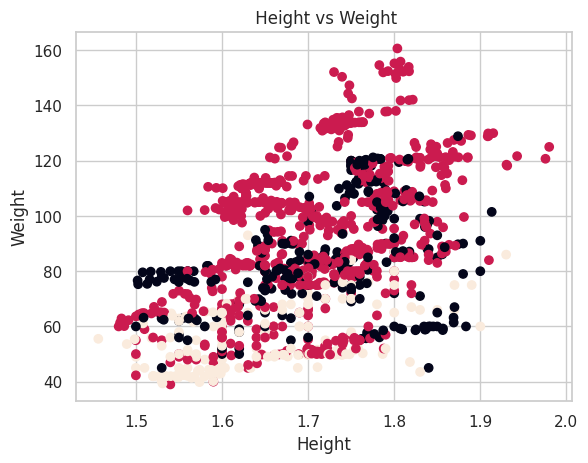

In [18]:
# TODO: Use ONLY the scaled obesity features (no target) for clustering.

# TODO: Choose the number of clusters k with the Elbow method (and/or silhouette score).
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
record4inertia=[]
record4silhouette=[]
for i in range(2,11):
  kmeans=KMeans(n_clusters=i,random_state=random_state)
  labels=kmeans.fit_predict(scaledxtrain)
  record4inertia.append(kmeans.inertia_)
  record4silhouette.append(silhouette_score(scaledxtrain,labels))

plt.plot(range(2, 11), record4inertia, marker='o')
plt.xlabel('Number of clusters k')
plt.ylabel('Inertia')
plt.title('Elbow Method')
plt.show()
#   Loop k = 2..10, record inertia_ (and silhouette), and plot inertia vs k.

# TODO: Fit KMeans with your chosen k (random_state=RANDOM_STATE) and get cluster labels.

# TODO: Visualise the clusters in 2D.
#   Pick two informative features (e.g. Weight vs Height) OR reduce to 2D with PCA
kmeans = KMeans(n_clusters=3, random_state=random_state)
cluster_labels = kmeans.fit_predict(scaledxtrain)

plt.scatter(xtrain['Height'], xtrain['Weight'], c=cluster_labels)
plt.xlabel('Height')
plt.ylabel('Weight')
plt.title(' Height vs Weight')
plt.show()
#   (from sklearn.decomposition import PCA) and colour points by cluster.


In [19]:
# TODO: How well do the clusters line up with the TRUE obesity levels?
#   Build a crosstab of cluster label vs the real NObeyesdad category:
table=pd.DataFrame({'label':cluster_labels, 'NObeyesdad':ytrain})
crosstab_result=pd.crosstab(table['label'], table['NObeyesdad'])
print(crosstab_result)
#   pd.crosstab(cluster_labels, obesity['NObeyesdad'])
#   Do some clusters map cleanly onto specific obesity levels?


NObeyesdad   0   1    2    3    4   5    6
label                                     
0           24  39   69   61    1  44   57
1           49  63  141  116  193  94  112
2           90  70    1    1    0  36    5


**Student Reasoning — Clustering**
*1. How did you choose k? Quote the Elbow/silhouette evidence.*
I realised that from 3 going, when you add more clusters it dooesnt really affect the inertia
*2. Looking at the crosstab, do the unsupervised clusters resemble the real obesity levels?
Where do they agree and where do they break down?*
Yeahh theres a little resemblance but theyre not the same
*3. In a real public-health setting where labels are expensive to collect, what would these
clusters be useful for?*
It can be used to gather patients who have certain attributes in common
> **Answer:** [Double-click to edit]


---
# Section 4 — Reflection

*Answer in a few sentences each:*

1. **Supervised vs unsupervised:** What did the classifier learn that K-Means could not, and
   vice-versa?
   Answer: K means did not know the labels but classfier did and was able to predict the right obesity
2. **Regression vs classification:** How did evaluating a continuous target (tips) differ from
   evaluating a categorical one (obesity level)?
   Answer: for regression i used RSME and R^2 and for classification i used accuracy, macro f1 and the confusion matrix
3. **Overfitting:** Across all three tasks, where did you see the biggest train-vs-test gap, and
   what is the single most effective thing you did (or would do) to close it?

> **Answer:** [Double-click to edit]


---
### Submission checklist

- [ ] All cells run top-to-bottom with no errors (`Kernel → Restart & Run All`).
- [ ] Every **Student Reasoning** box is filled in with full sentences.
- [ ] Plots are visible in the saved notebook.
- [ ] Notebook committed and pushed to your `lab-2-predictive-analytics` repository.
- [ ] Repository link submitted to the course portal.
- [ ] AI Declaration form in Repository

---
#### Grading guide (100 pts)
| Area | Pts |
|------|-----|
| Section 1 — Regression (load, preprocess, split, model, overfitting) | 30 |
| Section 2 — Classification (load, preprocess, stratified split, model, overfitting) | 30 |
| Section 3 — K-Means clustering (k selection, fit, visualise, compare) | 20 |
| Reasoning boxes & Section 4 reflection | 15 |
| Reproducibility (runs clean, random_state, tidy code) | 5 |
